# Red Sea SST — Yearly Comparison

This script reads Red Sea SST from Copernicus Marine, computes monthly means per year,
and produces  interactive plots:
1. **Spatial map** — monthly mean SST with a time slider, per year
2. **Seasonal cycle** — area-mean SST lines overlaid for each year

`version 1.0.2` `23.04.2026`

In [39]:
import copernicusmarine
import hvplot.xarray  # noqa
import warnings

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

In [40]:
import coiled

## Open dataset (lazy)

In [3]:
dataset_id = 'METOFFICE-GLO-SST-L4-NRT-OBS-SST-V2'
ds = copernicusmarine.open_dataset(dataset_id)
#ds

INFO - 2026-04-23T13:26:07Z - Downloading Copernicus Marine data requires a Copernicus Marine username and password, sign up for free at: https://data.marine.copernicus.eu/register


Copernicus Marine username:

  hhaile


Copernicus Marine password:

  ········


INFO - 2026-04-23T13:26:18Z - Selected dataset version: "default"
INFO - 2026-04-23T13:26:18Z - Selected dataset part: "default"


# Spatial subset for the Red Sea

# The Red Sea is a narrow basin located roughly between:
# latitude: 12°N–30°N
# longitude: 32°E–44°E

# Subsetting the dataset to focus only on this region allows
# efficient analysis of SST variability in the Red Sea.

In [4]:
ds

<xarray.Dataset> Size: 600GB
Dimensions:           (time: 827, latitude: 3600, longitude: 7200)
Coordinates:
  * latitude          (latitude) float32 14kB -89.97 -89.93 ... 89.93 89.97
  * longitude         (longitude) float32 29kB -180.0 -179.9 ... 179.9 180.0
  * time              (time) datetime64[ns] 7kB 2024-01-17 ... 2026-04-22
Data variables:
    analysed_sst      (time, latitude, longitude) float64 171GB dask.array<chunksize=(50, 1024, 2048), meta=np.ndarray>
    analysis_error    (time, latitude, longitude) float64 171GB dask.array<chunksize=(50, 1024, 2048), meta=np.ndarray>
    mask              (time, latitude, longitude) float32 86GB dask.array<chunksize=(50, 1024, 2048), meta=np.ndarray>
    sea_ice_fraction  (time, latitude, longitude) float64 171GB dask.array<chunksize=(50, 1024, 2048), meta=np.ndarray>
Attributes: (12/48)
    Conventions:                CF-1.4, ACDD-1.3
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    WARNING Some applications are unable to prope...
    creator_email:              enquiries@metoffice.gov.uk
    ...                         ...
    time_coverage_end:          20240119T000000Z
    time_coverage_start:        20240118T000000Z
    title:                      Global SST & Sea Ice Analysis, L4 OSTIA, 0.05...
    uuid:                       536d4865-f5a8-45b2-806f-1f1db491069a
    westernmost_longitude:      -180.0
    copernicusmarine_version:   2.3.0

In [5]:
# Spatial subset for the Red Sea
# The Red Sea is located approximately:
# Latitude: 12°N to 30°N
# Longitude: 32°E to 44°E
# Subsetting isolates the basin for regional SST analysis,
# allowing computation of seasonal and interannual variability.

ds_redsea = ds.sel(
    latitude=slice(12, 30),
    longitude=slice(32, 44)
)

# View dataset to confirm selection
ds_redsea

<xarray.Dataset> Size: 2GB
Dimensions:           (time: 827, latitude: 360, longitude: 240)
Coordinates:
  * latitude          (latitude) float32 1kB 12.02 12.07 12.12 ... 29.92 29.98
  * longitude         (longitude) float32 960B 32.03 32.08 32.12 ... 43.92 43.97
  * time              (time) datetime64[ns] 7kB 2024-01-17 ... 2026-04-22
Data variables:
    analysed_sst      (time, latitude, longitude) float64 572MB dask.array<chunksize=(50, 8, 240), meta=np.ndarray>
    analysis_error    (time, latitude, longitude) float64 572MB dask.array<chunksize=(50, 8, 240), meta=np.ndarray>
    mask              (time, latitude, longitude) float32 286MB dask.array<chunksize=(50, 8, 240), meta=np.ndarray>
    sea_ice_fraction  (time, latitude, longitude) float64 572MB dask.array<chunksize=(50, 8, 240), meta=np.ndarray>
Attributes: (12/48)
    Conventions:                CF-1.4, ACDD-1.3
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    WARNING Some applications are unable to prope...
    creator_email:              enquiries@metoffice.gov.uk
    ...                         ...
    time_coverage_end:          20240119T000000Z
    time_coverage_start:        20240118T000000Z
    title:                      Global SST & Sea Ice Analysis, L4 OSTIA, 0.05...
    uuid:                       536d4865-f5a8-45b2-806f-1f1db491069a
    westernmost_longitude:      -180.0
    copernicusmarine_version:   2.3.0

In [9]:
#cluster_type = 'Local'    
cluster_type = 'Coiled'
# cluster_type = 'Gateway'
#cluster_type = 'Coiled'

In [10]:
if cluster_type == 'Coiled':
    import coiled
    region="eu-central-1"
    cluster = coiled.Cluster(
        region=region,
        arm=True,   # run on ARM to save energy & cost
        worker_vm_types=["t4g.large"],  # cheap, small ARM instances, 2cpus, 2GB RAM 
        # worker_options={'nthreads':2}, # Amazon does not charge for this
        n_workers=30,
        name=f'hhaile_{region}',
        wait_for_workers=False,
        compute_purchase_option="spot_with_fallback",
        software='protocoast-notebook-arm',  # Conda environment name
        workspace='esip-lab',
        timeout=180   # leave cluster running for 3 min in case we want to use it again
    )

    client = cluster.get_client()

Output()

2026-04-23 14:11:26,057 - distributed.client - ERROR - Failed to reconnect to scheduler after 30.00 seconds, closing client


In [11]:
client

<Client: 'tls://10.0.30.120:8786' processes=30 threads=60, memory=214.82 GiB>

## Compute monthly means and convert to °C

Resample once on the full time axis, load the small result (~200 MB total),
then split by year — one `.load()` call for all years combined.

In [12]:
%%time
da_monthly = (
    ds_redsea ['analysed_sst']
    .resample(time='ME')   # 'ME' = month-end
    .mean()
    .load()
) - 273.15                 # kelvin to celcius

da_monthly.attrs['units'] = '°C'
# da_monthly

CPU times: user 830 ms, sys: 509 ms, total: 1.34 s
Wall time: 17.6 s


## Split by year

In [13]:
years = sorted({int(t) for t in da_monthly.time.dt.year.values})
da_by_year = {yr: da_monthly.sel(time=str(yr)) for yr in years}
print({yr: da.sizes for yr, da in da_by_year.items()})

{2024: Frozen({'time': 12, 'latitude': 360, 'longitude': 240}), 2025: Frozen({'time': 12, 'latitude': 360, 'longitude': 240}), 2026: Frozen({'time': 4, 'latitude': 360, 'longitude': 240})}


## Plot 1 — Spatial monthly SST maps with time slider

One panel per year, each with a month slider via `groupby='time'`.
Plots are laid out in two columns using `+` and `.cols(2)`.

In [14]:
map_opts = dict(                                                                                         
      x='longitude', y='latitude',                                                                         
      rasterize=True, geo=True,                                                                            
      cmap='turbo', clim=(-2, 25),                                                                         
      tiles='OSM',                                                                                         
      width=700, height=500,                                                                               
  )                                                                                                        

plot1 = da_monthly.hvplot(title='Red Sea SST Monthly Mean (°C)', groupby='time', **map_opts)
# plot1 = da_monthly.hvplot(title='Baltic SST Monthly Mean (°C)', **map_opts)                             
plot1

:DynamicMap   [time]
   :Overlay
      .WMTS.I  :WMTS   [Longitude,Latitude]
      .Image.I :Image   [longitude,latitude]   (analysed_sst)

## Plot 2 — Seasonal cycle: area-mean SST per year, all overlaid

Compute the red sea spatial mean for each monthly snapshot,
then plot all years as curves on the same axes using `*` to overlay.

In [15]:
import numpy as np
import pandas as pd

# Build a tidy DataFrame: month (1-12) vs year columns
records = {}
for yr, da in da_by_year.items():
    area_mean = da.mean(dim=['latitude', 'longitude']).values
    months = da.time.dt.month.values
    records[str(yr)] = pd.Series(area_mean, index=months)

df_seasonal = pd.DataFrame(records)
df_seasonal.index.name = 'month'
df_seasonal

,2024,2025,2026
month,,,
1,26.302575,26.067841,25.790910
2,25.625639,25.387284,25.788289
3,26.140996,25.622601,25.532038
4,27.611629,26.932211,26.589462
5,29.166990,28.198863,NaN
6,30.451656,29.415764,NaN
7,31.729008,30.875888,NaN
8,31.936640,31.300125,NaN
9,31.530719,31.027208,NaN


In [ ]:
#Red Sea SST — Monthly Area-Mean by Year

In [16]:
import hvplot.pandas  # noqa
import operator 
from functools import reduce 

COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

curves = [
    df_seasonal[col].hvplot.line(
        label=col,
        color=COLORS[i % len(COLORS)],
        line_width=2,
    )
    for i, col in enumerate(df_seasonal.columns)
]

seasonal_plot = reduce(operator.mul, curves).opts(
    title='Red Sea SST — Monthly Area-Mean by Year',
    xlabel='Month', ylabel='SST (°C)',
    legend_position='top_left',
    width=700, height=400,
    show_grid=True,
)
seasonal_plot

:Overlay
   .Curve.A_2024 :Curve   [month]   (2024)
   .Curve.A_2025 :Curve   [month]   (2025)
   .Curve.A_2026 :Curve   [month]   (2026)

In [ ]:
#Seasonal pattern analysis converts Red Sea SST data into a monthly North vs South comparison table for analysis and plotting.

In [49]:
#This code splits the Red Sea into north and south regions so you can analyze spatial climate gradients and 
#seasonal temperature differences.
##This code takes raw satellite SST data, converts it into monthly averages, 
#transforms Kelvin to Celsius, and produces clean time series for South and North Red Sea.
## title="Red Sea SST: North vs South Seasonal Cycle"
import matplotlib.pyplot as plt

# 1️⃣ Split Red Sea into South and North
ds_red_south = ds.sel(latitude=slice(12, 20), longitude=slice(32, 44))
ds_red_north = ds.sel(latitude=slice(20, 30), longitude=slice(32, 44))

# 2️⃣ Compute monthly SST (°C)
da_south = (
    ds_red_south['analysed_sst']
    .resample(time='ME')
    .mean()
    .load()
) - 273.15

da_north = (
    ds_red_north['analysed_sst']
    .resample(time='ME')
    .mean()
    .load()
) - 273.15

# 3️⃣ Spatial average → time series
south_temp = da_south.mean(dim=["latitude", "longitude"])
north_temp = da_north.mean(dim=["latitude", "longitude"])

# 4️⃣ Plot comparison
plt.figure(figsize=(10,6))

plt.plot(south_temp.time, south_temp, label="South Red Sea")
plt.plot(north_temp.time, north_temp, label="North Red Sea")

plt.title("Red Sea SST: North vs South")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid()

plt.show()

AttributeError: 'NoneType' object has no attribute 'sel'

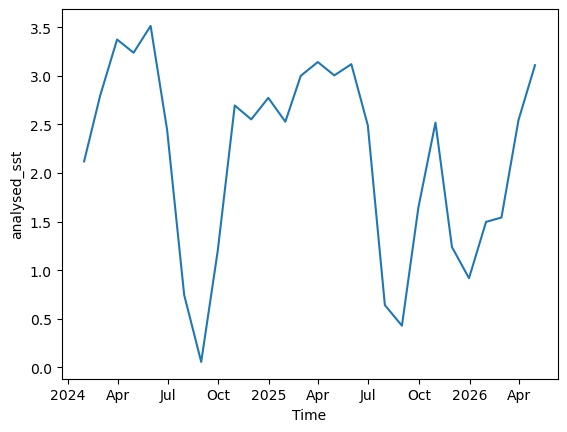

In [33]:
#This line calculates how much warmer the South Red Sea is compared to the North at each time step
sst_diff = da_south.mean(dim=["latitude", "longitude"]) - da_north.mean(dim=["latitude", "longitude"])
sst_diff.plot()

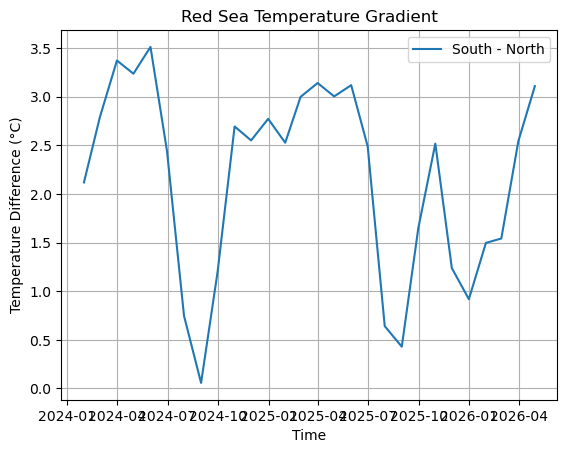

In [35]:
##Compute expansion index
#This code calculates and plots how the temperature difference between South and North Red Sea changes over time, 
#which acts as a proxy for thermal gradient strength and expansion tendency
import matplotlib.pyplot as plt

plt.figure()

plt.plot(expansion_diff.time, expansion_diff, label="South - North")

plt.title("Red Sea Temperature Gradient")
plt.xlabel("Time")
plt.ylabel("Temperature Difference (°C)")
plt.legend()
plt.grid()

plt.show()

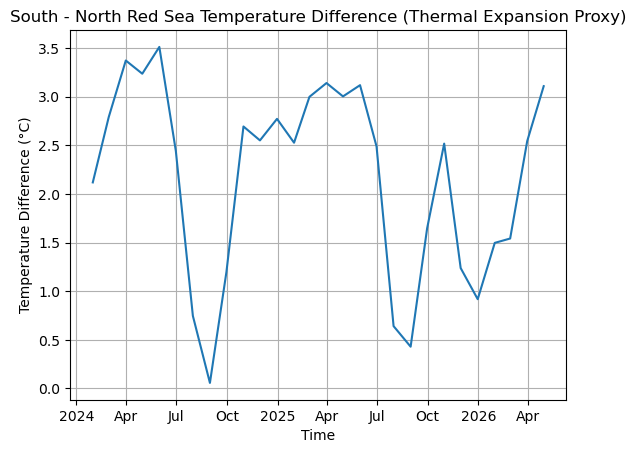

In [37]:
##expansion_proxy
#This code computes and plots how much warmer the South Red Sea is compared to the North over time,
#import matplotlib.pyplot as plt

expansion_proxy.plot()

plt.title("South - North Red Sea Temperature Difference (Thermal Expansion Proxy)")
plt.xlabel("Time")
plt.ylabel("Temperature Difference (°C)")
plt.grid()

plt.show()
#showing the internal thermal gradient of the basin

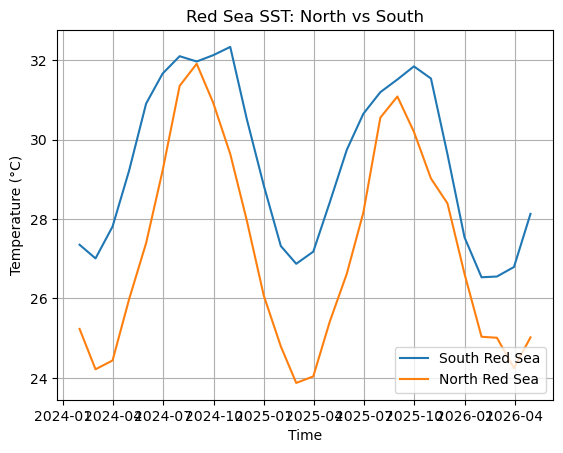

In [27]:
#Your code plots South and North Red Sea SST as two time series to visually
#compare climate variability and temperature differences over time.
#This is important for ocean heat distribution
#evaporation asymmetry
#steric expansion potential

import matplotlib.pyplot as plt

plt.figure()

plt.plot(south_temp.time, south_temp, label="South Red Sea")
plt.plot(north_temp.time, north_temp, label="North Red Sea")

plt.title("Red Sea SST: North vs South")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid()
plt.show()

In [28]:
expansion_diff > 0

<xarray.DataArray 'analysed_sst' (time: 28)> Size: 28B
array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])
Coordinates:
  * time     (time) datetime64[ns] 224B 2024-01-31 2024-02-29 ... 2026-04-30

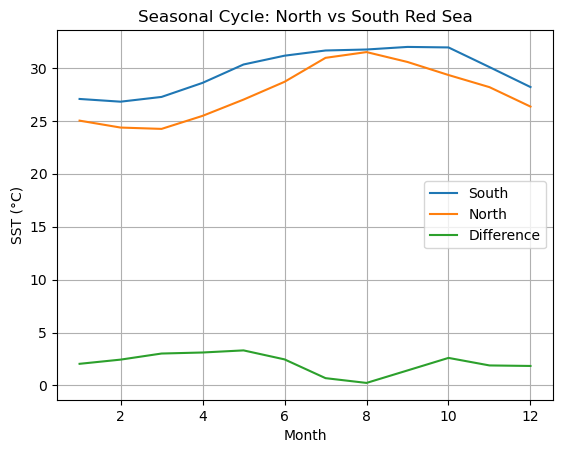

In [38]:
#This workflow:

#extracts SST from South and North Red Sea
#computes spatial averages (one value per time step)
#builds a monthly climatology (seasonal cycle)
#compares North vs South
#optionally computes the temperature difference

import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Compute spatial averages (time series)
south_temp = da_south.mean(dim=["latitude", "longitude"])
north_temp = da_north.mean(dim=["latitude", "longitude"])

# 👉 Now we have:
# south_temp(time) and north_temp(time)

# 2️⃣ Build DataFrame with month index
df = pd.DataFrame({
    "South": south_temp.values,
    "North": north_temp.values
}, index=south_temp.time.dt.month)

# 👉 Index = month (1–12)

# 3️⃣ Compute seasonal climatology (average across years)
seasonal = df.groupby(level=0).mean().sort_index()

# 4️⃣ Add temperature difference (gradient)
seasonal["Difference"] = seasonal["South"] - seasonal["North"]

# 5️⃣ Plot seasonal cycle
seasonal.plot()

plt.title("Seasonal Cycle: North vs South Red Sea")
plt.xlabel("Month")
plt.ylabel("SST (°C)")
plt.grid()

plt.show()

In [ ]:
##GOAL (what you are trying to reach)
##You want:

#📈 Steric sea level change (thermal expansion of the ocean)

#That requires:

#✔ Temperature in 3D (T(z))
#✔ Salinity (S(z))
#✔ Pressure / depth (z or p)

In [ ]:
import copernicusmarine
import xarray as xr

# 🌍 1. SEARCH AVAILABLE OCEAN REANALYSIS DATASETS
# (FIX: contains must be a LIST)
results = copernicusmarine.describe(
    contains=["ocean"]
)

print(results)


# 🌊 2. OPTIONAL: more targeted search (temperature + salinity)
results2 = copernicusmarine.describe(
    contains=["temperature", "salinity"]
)

print(results2)


# 🔍 3. AFTER YOU IDENTIFY THE CORRECT DATASET ID
# 👉 replace "PUT_DATASET_ID_HERE" with real one from output

dataset_id = "PUT_DATASET_ID_HERE"

ds = copernicusmarine.open_dataset(dataset_id)


# 📊 4. Inspect dataset structure
print(ds)

# 🌡️ 5. Check variables (thetao = temperature, so = salinity)
print(ds.data_vars)

# 📏 6. Check dimensions (time, depth, lat, lon)
print(ds.dims)


# 🌊 7. Quick sanity check (surface temperature)
# (adjust variable name if needed after inspection)
if "thetao" in ds:
    ds["thetao"].isel(time=0, depth=0).plot()